# Building 4 & 6: feature-based electricity-use model comparison

Run this one notebook from top to bottom. The first section creates `series_testing_dataset`; the later sections create features, train models and compare results.


# Converting Energy Demand and Power Production TSF to Pandas Dataframe
Essentialy, this is just imported code from a github repository provided. It takes the TSF data file and converts it into a Pandas Dataframe for use in Python


In [1]:
from datetime import datetime
from distutils.util import strtobool

import pandas as pd


# Converts the contents in a .tsf file into a dataframe and returns it along with other meta-data of the dataset: frequency, horizon, whether the dataset contains missing values and whether the series have equal lengths
#
# Parameters
# full_file_path_and_name - complete .tsf file path
# replace_missing_vals_with - a term to indicate the missing values in series in the returning dataframe
# value_column_name - Any name that is preferred to have as the name of the column containing series values in the returning dataframe
def convert_tsf_to_dataframe(
    full_file_path_and_name,
    replace_missing_vals_with="NaN",
    value_column_name="series_value",
):
    col_names = []
    col_types = []
    all_data = {}
    line_count = 0
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    found_data_tag = False
    found_data_section = False
    started_reading_data_section = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            # Strip white space from start/end of line
            line = line.strip()

            if line:
                if line.startswith("@"):  # Read meta-data
                    if not line.startswith("@data"):
                        line_content = line.split(" ")
                        if line.startswith("@attribute"):
                            if (
                                len(line_content) != 3
                            ):  # Attributes have both name and type
                                raise Exception("Invalid meta-data specification.")

                            col_names.append(line_content[1])
                            col_types.append(line_content[2])
                        else:
                            if (
                                len(line_content) != 2
                            ):  # Other meta-data have only values
                                raise Exception("Invalid meta-data specification.")

                            if line.startswith("@frequency"):
                                frequency = line_content[1]
                            elif line.startswith("@horizon"):
                                forecast_horizon = int(line_content[1])
                            elif line.startswith("@missing"):
                                contain_missing_values = bool(
                                    strtobool(line_content[1])
                                )
                            elif line.startswith("@equallength"):
                                contain_equal_length = bool(strtobool(line_content[1]))

                    else:
                        if len(col_names) == 0:
                            raise Exception(
                                "Missing attribute section. Attribute section must come before data."
                            )

                        found_data_tag = True
                elif not line.startswith("#"):
                    if len(col_names) == 0:
                        raise Exception(
                            "Missing attribute section. Attribute section must come before data."
                        )
                    elif not found_data_tag:
                        raise Exception("Missing @data tag.")
                    else:
                        if not started_reading_data_section:
                            started_reading_data_section = True
                            found_data_section = True
                            all_series = []

                            for col in col_names:
                                all_data[col] = []

                        full_info = line.split(":")

                        if len(full_info) != (len(col_names) + 1):
                            raise Exception("Missing attributes/values in series.")

                        series = full_info[len(full_info) - 1]
                        series = series.split(",")

                        if len(series) == 0:
                            raise Exception(
                                "A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series. Missing values should be indicated with ? symbol"
                            )

                        numeric_series = []

                        for val in series:
                            if val == "?":
                                numeric_series.append(replace_missing_vals_with)
                            else:
                                numeric_series.append(float(val))

                        if numeric_series.count(replace_missing_vals_with) == len(
                            numeric_series
                        ):
                            raise Exception(
                                "All series values are missing. A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series."
                            )

                        all_series.append(pd.Series(numeric_series).array)

                        for i in range(len(col_names)):
                            att_val = None
                            if col_types[i] == "numeric":
                                att_val = int(full_info[i])
                            elif col_types[i] == "string":
                                att_val = str(full_info[i])
                            elif col_types[i] == "date":
                                att_val = datetime.strptime(
                                    full_info[i], "%Y-%m-%d %H-%M-%S"
                                )
                            else:
                                raise Exception(
                                    "Invalid attribute type."
                                )  # Currently, the code supports only numeric, string and date types. Extend this as required.

                            if att_val is None:
                                raise Exception("Invalid attribute value.")
                            else:
                                all_data[col_names[i]].append(att_val)

                line_count = line_count + 1

        if line_count == 0:
            raise Exception("Empty file.")
        if len(col_names) == 0:
            raise Exception("Missing attribute section.")
        if not found_data_section:
            raise Exception("Missing series information under data section.")

        all_data[value_column_name] = all_series
        loaded_data = pd.DataFrame(all_data)

        return (
            loaded_data,
            frequency,
            forecast_horizon,
            contain_missing_values,
            contain_equal_length,
        )


# Example of usage
# loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe("TSForecasting/tsf_data/sample.tsf")

# print(loaded_data)
# print(frequency)
# print(forecast_horizon)
# print(contain_missing_values)
# print(contain_equal_length)


In [2]:
testing_dataset = convert_tsf_to_dataframe(
    r"C:\Users\50851\Desktop\ADS2002\MonashSolarFarm\phase_1_data.tsf",
    replace_missing_vals_with="NaN",
    value_column_name="series_value"
)


# Converting the Solar DataFrame to a Timeseries
To actually analyse the data, the dataframe has to be converted to a timeseries dataframe. Originally, the dataset from converting the dataset only provided each Building and Respective Solar, the time which the data for each buildings data starts, and the actual values of the time series in a list.

Essentially a new dataset was made with index starting from the earliest recorded time from all the buildings and Solar, to the end of September, as according to the project. After, the Buildings and Solar from the original data set were made the columns of the new time_series data set.

To fill in the new dataset, the list of the time series for each building were set to start when the timestamp was, alllocated to the specific timeseries row in the new dataset. With this, the new dataset was now a timeseries with all values for each building and solar in each correct sport respecitvely.


In [3]:
real_set = testing_dataset[0]
real_set


,series_name,start_timestamp,series_value
0,Building0,2016-07-03 21:30:00,"[283.8, 283.8, 283.8, 606.0, 606.0, 606.0, 606..."
1,Building1,2019-01-09 23:15:00,"[8.1, 15.7, 22.8, 32.7, 8.1, 16.5, 24.7, 34.5,..."
2,Building3,2016-03-01 04:15:00,"[1321.0, 1321.0, 1321.0, 1321.0, 1293.0, 1293...."
3,Building4,2019-07-03 04:45:00,"[2.0, NaN, 1.0, 2.0, NaN, 2.0, NaN, NaN, 2.0, ..."
4,Building5,2019-07-25 23:00:00,"[30.0, 31.0, 24.0, 34.0, 30.0, 31.0, 26.0, 33...."
5,Building6,2019-07-25 01:45:00,"[36.8, 34.6, 34.6, 36.2, 36.2, 35.2, 35.2, 35...."
6,Solar0,2020-04-25 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,Solar1,2018-12-31 13:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,Solar2,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,Solar3,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [4]:
index = pd.date_range(start="2016-03-01 04:15:00", end="2020-09-30 23:59:45", freq="15min")
new_headers = real_set["series_name"].dropna().unique().tolist()

series_testing_dataset = pd.DataFrame(columns = new_headers,index = index)

for _, row in real_set.iterrows():

    column = row.series_name
    start_time = pd.to_datetime(row.start_timestamp)
    values = row.series_value

    start_time_index = series_testing_dataset.index.get_loc(start_time)

    series_testing_dataset.iloc[0:start_time_index, series_testing_dataset.columns.get_loc(column)] = 0
    series_testing_dataset.iloc[start_time_index:start_time_index + len(values),series_testing_dataset.columns.get_loc(column)] = values

series_testing_dataset = series_testing_dataset.apply(pd.to_numeric,errors='coerce')
series_testing_dataset


,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 04:15:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:30:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:45:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:00:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:15:00,0.0,0.0,1293.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,14.4,389.0,NaN,NaN,35.6,29.67,6.68,6.34,5.49,4.55,25.28
2020-09-30 23:00:00,96.9,18.8,389.0,1.0,NaN,38.6,29.94,6.71,6.39,5.65,4.57,25.30
2020-09-30 23:15:00,37.4,4.5,415.0,NaN,NaN,38.6,34.02,8.13,7.71,6.83,5.32,28.62
2020-09-30 23:30:00,37.4,9.6,415.0,NaN,NaN,38.6,38.10,9.55,9.03,8.02,6.08,31.94


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

WEATHER_PATH = Path(r"C:\Users\50851\Desktop\ADS2002\MonashSolarFarm\ERA5_Weather_Data_Monash.csv")
OUTPUT_DIR = Path.cwd() / "building4_6_clean_model_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42


## 1. Select genuine Building 4 and Building 6 observations

Only known valid periods are retained; the padded missing period is not used as zero electricity usage.


In [ ]:
base_dataframe = series_testing_dataset.copy()
base_dataframe.index = pd.to_datetime(base_dataframe.index)
base_dataframe = base_dataframe.sort_index()

# Select every actual observation after the building's true start timestamp.
# Any missing timestamp remains missing (it is never converted into zero usage).
raw_buildings = {}
for building in ["Building4", "Building6"]:
    first_start = pd.to_datetime(
        real_set.loc[real_set["series_name"] == building, "start_timestamp"].min()
    )
    observed = base_dataframe.loc[first_start:, building].dropna()
    raw_buildings[building] = observed
    print(f"{building}: {len(observed):,} complete available observations; {observed.index.min()} to {observed.index.max()}; min={observed.min():.3f}, max={observed.max():.3f}")

hourly_buildings = {building: values.resample("1h").mean().dropna() for building, values in raw_buildings.items()}


## 2. Build the supplied `Feature_dataset`

The next two cells are copied from `FEATURES_CODE.ipynb`. They create the supplied weekday, semester, break, examination, public-holiday and COVID features.


In [10]:
import pandas as pd 

index = pd.date_range(start="2016-01-01 00:00:00", end="2020-09-30 23:59:45", freq="15min")
Feature_dataset = pd.DataFrame(index = index)

print('Feature_dataset base shape:', Feature_dataset.shape)


""
2016-01-01 00:00:00
2016-01-01 00:15:00
2016-01-01 00:30:00
2016-01-01 00:45:00
2016-01-01 01:00:00
...
2020-09-30 22:45:00
2020-09-30 23:00:00
2020-09-30 23:15:00
2020-09-30 23:30:00


In [11]:
import pandas as pd
import numpy as np

# ============================================================
# 0. PREPARE DATETIME INDEX
# ============================================================

Feature_dataset.index = pd.to_datetime(Feature_dataset.index)
Feature_dataset = Feature_dataset.sort_index()

date = Feature_dataset.index.normalize()
hour = Feature_dataset.index.hour
minute = Feature_dataset.index.minute
time_minutes = hour * 60 + minute


# ============================================================
# 1. HELPER FUNCTION FOR DATE RANGES
# ============================================================

def in_date_ranges(index, ranges):
    dates = index.normalize()
    mask = pd.Series(False, index=index)

    for start, end in ranges:
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        mask |= (dates >= start) & (dates <= end)

    return mask.astype(int).values


# ============================================================
# 2. WEEKDAY / WEEKEND
# ============================================================

Feature_dataset["is_weekday"] = (
    Feature_dataset.index.dayofweek < 5
).astype(int)

Feature_dataset["is_weekend"] = (
    Feature_dataset.index.dayofweek >= 5
).astype(int)


# ============================================================
# 3. UNIVERSITY OPEN / CLOSED
# ============================================================

university_open_ranges = [
    ("2016-01-04", "2016-12-22"),
    ("2017-01-03", "2017-12-21"),
    ("2018-01-02", "2018-12-21"),
    ("2019-01-02", "2019-12-23"),
    ("2020-01-02", "2020-12-23"),
]

Feature_dataset["university_open"] = in_date_ranges(
    Feature_dataset.index,
    university_open_ranges
)

Feature_dataset["university_closed"] = (
    1 - Feature_dataset["university_open"]
)


# ============================================================
# 4. CAMPUS FACILITY HOURS
# Mon-Fri: 09:00 - 17:00
# ============================================================

campus_time_open = (
    (time_minutes >= 9 * 60) &
    (time_minutes < 17 * 60)
)

Feature_dataset["campus_facility_hours"] = (
    (Feature_dataset["is_weekday"] == 1) &
    campus_time_open
).astype(int)


# ============================================================
# 5. LIBRARY OPENING HOURS
#
# Weekdays: 08:00 - 22:00
# Weekends: 10:00 - 17:00
# ============================================================

weekday_library = (
    (Feature_dataset["is_weekday"] == 1) &
    (time_minutes >= 8 * 60) &
    (time_minutes < 22 * 60)
)

weekend_library = (
    (Feature_dataset["is_weekend"] == 1) &
    (time_minutes >= 10 * 60) &
    (time_minutes < 17 * 60)
)

Feature_dataset["library_open_hours"] = (
    weekday_library | weekend_library
).astype(int)


# ============================================================
# 6. SEMESTER 1
# ============================================================

semester_1_ranges = [
    ("2016-02-29", "2016-05-27"),
    ("2017-02-21", "2017-05-26"),
    ("2018-02-26", "2018-05-25"),
    ("2019-03-04", "2019-05-31"),
    ("2020-03-09", "2020-06-12"),
]

Feature_dataset["semester_1"] = in_date_ranges(
    Feature_dataset.index,
    semester_1_ranges
)


# ============================================================
# 7. SEMESTER 2
# ============================================================

semester_2_ranges = [
    ("2016-07-25", "2016-10-21"),
    ("2017-07-24", "2017-10-20"),
    ("2018-07-23", "2018-10-19"),
    ("2019-07-29", "2019-10-25"),
    ("2020-08-03", "2020-11-06"),
]

Feature_dataset["semester_2"] = in_date_ranges(
    Feature_dataset.index,
    semester_2_ranges
)

Feature_dataset["semester_active"] = (
    (Feature_dataset["semester_1"] == 1) |
    (Feature_dataset["semester_2"] == 1)
).astype(int)


# ============================================================
# 8. MID-SEMESTER BREAK
# ============================================================

mid_sem_break_ranges = [
    ("2016-03-25", "2016-04-01"),
    ("2016-09-26", "2016-09-30"),

    ("2017-04-14", "2017-04-21"),
    ("2017-09-25", "2017-09-29"),

    ("2018-03-30", "2018-04-06"),
    ("2018-09-24", "2018-09-28"),

    ("2019-04-19", "2019-04-26"),
    ("2019-09-30", "2019-10-04"),

    ("2020-04-10", "2020-04-17"),
    ("2020-09-21", "2020-10-02"),
]

Feature_dataset["mid_sem_break"] = in_date_ranges(
    Feature_dataset.index,
    mid_sem_break_ranges
)


# ============================================================
# 9. ORIENTATION WEEK
# ============================================================

orientation_ranges = [
    ("2016-02-22", "2016-02-26"),
    ("2016-07-18", "2016-07-22"),

    ("2017-02-20", "2017-02-24"),
    ("2017-07-17", "2017-07-21"),

    ("2018-02-19", "2018-02-23"),
    ("2018-07-16", "2018-07-20"),

    ("2019-02-25", "2019-03-01"),
    ("2019-07-22", "2019-07-26"),

    # Semester 1 2020 not listed
    ("2020-07-27", "2020-07-31"),
]

Feature_dataset["orientation_week"] = in_date_ranges(
    Feature_dataset.index,
    orientation_ranges
)


# ============================================================
# 10. SWOT VAC
# ============================================================

swotvac_ranges = [
    ("2016-05-30", "2016-06-03"),
    ("2016-10-24", "2016-10-28"),

    ("2017-05-29", "2017-06-02"),
    ("2017-10-23", "2017-10-27"),

    ("2018-05-28", "2018-06-01"),
    ("2018-10-22", "2018-10-26"),

    ("2019-06-03", "2019-06-07"),
    ("2019-10-28", "2019-11-01"),

    ("2020-06-15", "2020-06-19"),
    ("2020-11-09", "2020-11-13"),
]

Feature_dataset["swotvac"] = in_date_ranges(
    Feature_dataset.index,
    swotvac_ranges
)


# ============================================================
# 11. EXAM PERIOD
# ============================================================

exam_ranges = [
    ("2016-06-06", "2016-06-24"),
    ("2016-10-31", "2016-11-18"),

    ("2017-06-05", "2017-06-23"),
    ("2017-10-30", "2017-11-17"),

    ("2018-06-04", "2018-06-22"),
    ("2018-10-29", "2018-11-16"),

    ("2019-06-10", "2019-06-28"),
    ("2019-11-04", "2019-11-22"),

    ("2020-06-22", "2020-07-10"),
    ("2020-11-16", "2020-12-04"),
]

Feature_dataset["exam_period"] = in_date_ranges(
    Feature_dataset.index,
    exam_ranges
)


# ============================================================
# 12. REMOTE EXAMS - 2020
# ============================================================

Feature_dataset["remote_exam"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-06-22", "2020-07-10")]
)


# ============================================================
# 13. PUBLIC HOLIDAYS
# ============================================================

public_holidays = pd.to_datetime([

    # 2016
    "2016-01-26",
    "2016-03-25",
    "2016-03-28",
    "2016-03-29",
    "2016-04-25",
    "2016-09-30",
    "2016-12-25",
    "2016-12-26",

    # 2017
    "2017-01-26",
    "2017-04-14",
    "2017-04-17",
    "2017-04-18",
    "2017-04-25",
    "2017-09-29",
    "2017-12-25",
    "2017-12-26",

    # 2018
    "2018-01-01",
    "2018-01-26",
    "2018-03-30",
    "2018-04-02",
    "2018-04-03",
    "2018-04-25",
    "2018-09-28",
    "2018-12-25",
    "2018-12-26",

    # 2019
    "2019-01-01",
    "2019-01-28",
    "2019-04-19",
    "2019-04-22",
    "2019-04-23",
    "2019-04-25",
    "2019-09-27",
    "2019-12-25",
    "2019-12-26",

    # 2020
    "2020-01-01",
    "2020-01-27",
    "2020-04-10",
    "2020-04-13",
    "2020-04-14",
    "2020-04-25",
    "2020-10-23",
    "2020-12-25",
    "2020-12-28",
])

Feature_dataset["public_holiday"] = (
    date.isin(public_holidays)
).astype(int)


# ============================================================
# 14. COVID DISRUPTION
# 9 March 2020 onward
# ============================================================

Feature_dataset["covid_disruption"] = (
    date >= pd.Timestamp("2020-03-09")
).astype(int)


# ============================================================
# 15. ONLINE CLASSES
# 9 - 13 March 2020
# ============================================================

Feature_dataset["online_classes"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-03-09", "2020-03-13")]
)


# ============================================================
# 16. COVID CAMPUS RESTRICTIONS
# 16 March - 18 October 2020
# ============================================================

Feature_dataset["covid_restrictions"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-03-16", "2020-10-18")]
)


# ============================================================
# 17. COVID CURFEW PERIOD
# 2 August - 13 September 2020
# ============================================================

Feature_dataset["covid_curfew_period"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-08-02", "2020-09-13")]
)


# ============================================================
# 18. EFFECTIVE CAMPUS OPEN
#
# Combines:
# - University open
# - Weekday
# - 9am-5pm
# - Not public holiday
# - Not COVID restricted
# ============================================================

Feature_dataset["campus_facility_effectively_open"] = (
    (Feature_dataset["university_open"] == 1) &
    (Feature_dataset["is_weekday"] == 1) &
    campus_time_open &
    (Feature_dataset["public_holiday"] == 0) &
    (Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# 19. EFFECTIVE LIBRARY OPEN
# ============================================================

Feature_dataset["library_effectively_open"] = (
    (Feature_dataset["library_open_hours"] == 1) &
    (Feature_dataset["university_open"] == 1) &
    (Feature_dataset["public_holiday"] == 0) &
    (Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# 20. TEACHING DAY
# ============================================================

Feature_dataset["teaching_day"] = (
    (Feature_dataset["semester_active"] == 1) &
    (Feature_dataset["is_weekday"] == 1) &
    (Feature_dataset["mid_sem_break"] == 0) &
    (Feature_dataset["public_holiday"] == 0)
).astype(int)


# ============================================================
# 21. CHECK THE CREATED FEATURES
# ============================================================

feature_columns = [
    "is_weekday",
    "is_weekend",
    "university_open",
    "university_closed",
    "campus_facility_hours",
    "library_open_hours",
    "semester_1",
    "semester_2",
    "semester_active",
    "mid_sem_break",
    "orientation_week",
    "swotvac",
    "exam_period",
    "remote_exam",
    "public_holiday",
    "covid_disruption",
    "online_classes",
    "covid_restrictions",
    "covid_curfew_period",
    "campus_facility_effectively_open",
    "library_effectively_open",
    "teaching_day",
]

print(Feature_dataset[feature_columns].head())
print("\nFeature counts:")
print(Feature_dataset[feature_columns].sum())


                     is_weekday  is_weekend  university_open  \
2016-01-01 00:00:00           1           0                0   
2016-01-01 00:15:00           1           0                0   
2016-01-01 00:30:00           1           0                0   
2016-01-01 00:45:00           1           0                0   
2016-01-01 01:00:00           1           0                0   

                     university_closed  campus_facility_hours  \
2016-01-01 00:00:00                  1                      0   
2016-01-01 00:15:00                  1                      0   
2016-01-01 00:30:00                  1                      0   
2016-01-01 00:45:00                  1                      0   
2016-01-01 01:00:00                  1                      0   

                     library_open_hours  semester_1  semester_2  \
2016-01-01 00:00:00                   0           0           0   
2016-01-01 00:15:00                   0           0           0   
2016-01-01 00:30:00    

## 3. Combine the supplied features with weather and building usage


In [ ]:
# Convert the supplied 15-minute feature dataframe to hourly features for the hourly usage target.
# `max()` preserves a binary feature when it occurs in any part of that hour.
hourly_feature_dataset = Feature_dataset.resample("1h").max()

# Remove only exact duplicate/complement calendar encodings. This prevents an
# unstable ordinary linear-regression solution while retaining the supplied features.
hourly_feature_dataset = hourly_feature_dataset.drop(
    columns=["is_weekend", "university_closed", "semester_active"], errors="ignore"
)

# Add continuous clock variables as supplementary time features; the supplied Feature_dataset remains the calendar base.
hour = hourly_feature_dataset.index.hour
hourly_feature_dataset["hour_sin"] = np.sin(2 * np.pi * hour / 24)
hourly_feature_dataset["hour_cos"] = np.cos(2 * np.pi * hour / 24)
hourly_feature_dataset["month_sin"] = np.sin(2 * np.pi * hourly_feature_dataset.index.month / 12)
hourly_feature_dataset["month_cos"] = np.cos(2 * np.pi * hourly_feature_dataset.index.month / 12)

weather = pd.read_csv(WEATHER_PATH)
weather.index = pd.to_datetime(weather["datetime (UTC)"])
weather = weather.drop(columns=["datetime (UTC)", "coordinates (lat,lon)", "model (name)", "utc_offset (hrs)"], errors="ignore")
weather = weather.select_dtypes(include="number").resample("1h").mean()

model_datasets = {}
for building, hourly in hourly_buildings.items():
    dataset = hourly_feature_dataset.reindex(hourly.index).join(weather, how="left")
    dataset["usage"] = hourly

    # Historical-use features: every value is shifted into the future before joining,
    # so the model never sees the current or future target when predicting an hour.
    dataset["usage_lag_1h"] = hourly.shift(freq="1h").reindex(dataset.index)
    dataset["usage_lag_24h"] = hourly.shift(freq="24h").reindex(dataset.index)
    dataset["usage_lag_168h"] = hourly.shift(freq="168h").reindex(dataset.index)
    dataset["usage_rolling_mean_24h"] = hourly.shift(freq="1h").rolling("24h", min_periods=12).mean().reindex(dataset.index)

    # Drop only rows with unavailable target/history. Weather gaps remain imputed in the pipeline.
    dataset = dataset.dropna(subset=["usage", "usage_lag_1h", "usage_lag_24h", "usage_lag_168h"]).sort_index()
    model_datasets[building] = dataset
    dataset.to_csv(OUTPUT_DIR / f"{building}_feature_dataset.csv")
    print(building, dataset.shape, "zero-usage share:", round((dataset["usage"] == 0).mean(), 3))


## 4. Chronological training/testing split and model list


In [4]:
def make_models():
    scaled = lambda m: Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", m)])
    unscaled = lambda m: Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", m)])
    return {
        "Linear Regression": scaled(LinearRegression()),
        "Ridge Regression": scaled(Ridge(alpha=1.0)),
        "Decision Tree": unscaled(DecisionTreeRegressor(max_depth=16, min_samples_leaf=5, random_state=RANDOM_STATE)),
        "Random Forest": unscaled(RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1)),
        "KNN": scaled(KNeighborsRegressor(n_neighbors=12, weights="distance")),
        "SVM (SVR)": scaled(SVR(C=20, epsilon=0.05, kernel="rbf")),
        "Gradient Boosting": unscaled(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)),
        "XGBoost": unscaled(XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1)),
        "Neural Network": scaled(MLPRegressor(hidden_layer_sizes=(16,), early_stopping=True, validation_fraction=0.1, max_iter=50, random_state=RANDOM_STATE)),
    }

def score(y_true, prediction):
    nonzero = y_true != 0
    return {
        "MAE": mean_absolute_error(y_true, prediction),
        "RMSE": mean_squared_error(y_true, prediction) ** 0.5,
        "R2": r2_score(y_true, prediction),
        "MAPE_nonzero_pct": (np.mean(np.abs((y_true[nonzero] - prediction[nonzero]) / y_true[nonzero])) * 100) if nonzero.any() else np.nan,
        "Within_10pct_match_rate": (np.mean(np.abs(y_true[nonzero] - prediction[nonzero]) / y_true[nonzero] <= 0.10) * 100) if nonzero.any() else np.nan,
    }


## 5. Train all models and compare on unseen data


In [5]:
all_results, all_predictions = [], []

for building, data in model_datasets.items():
    features = [column for column in data.columns if column != "usage"]
    split = int(len(data) * 0.80)  # newest 20% is never seen during training
    train, test = data.iloc[:split], data.iloc[split:]
    X_train, y_train = train[features], train["usage"]
    X_test, y_test = test[features], test["usage"]
    # A representative, evenly spaced sample keeps SVM and Neural Network fast enough to compare fairly.
    if len(X_train) > 3000:
        sample_positions = np.linspace(0, len(X_train) - 1, 3000, dtype=int)
        X_train, y_train = X_train.iloc[sample_positions], y_train.iloc[sample_positions]
    print(f"\n{building}: training={len(train):,}; testing={len(test):,}; test period={test.index.min()} to {test.index.max()}")

    for name, model in make_models().items():
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        result = {"Building": building, "Model": name, **score(y_test.to_numpy(), prediction)}
        all_results.append(result)
        all_predictions.append(pd.DataFrame({"datetime": test.index, "Building": building, "Model": name, "Actual": y_test.to_numpy(), "Predicted": prediction}))
        print(f"  {name}: RMSE={result['RMSE']:.3f}, match within 10%={result['Within_10pct_match_rate']:.1f}%")

results = pd.DataFrame(all_results).sort_values(["Building", "RMSE"]).reset_index(drop=True)
predictions = pd.concat(all_predictions, ignore_index=True)
results.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
display(results.round(3))



Building4: training=8,419; testing=2,105; test period=2020-06-30 05:00:00 to 2020-09-30 23:00:00
  Linear Regression: RMSE=0.445, match within 10%=22.8%
  Ridge Regression: RMSE=0.446, match within 10%=22.8%
  Decision Tree: RMSE=0.483, match within 10%=31.6%


  Random Forest: RMSE=0.439, match within 10%=26.7%


C:\Users\50851\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\50851\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


  KNN: RMSE=0.468, match within 10%=22.2%


  SVM (SVR): RMSE=0.640, match within 10%=16.7%


...

  Gradient Boosting: RMSE=2.888, match within 10%=77.0%


  XGBoost: RMSE=2.659, match within 10%=80.7%


  Neural Network: RMSE=3.855, match within 10%=61.4%


C:\Users\50851\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


,Building,Model,MAE,RMSE,R2,MAPE_nonzero_pct,Within_10pct_match_rate
0,Building4,XGBoost,0.325,0.439,0.132,22.654,27.506
1,Building4,Random Forest,0.330,0.439,0.131,23.323,26.746
2,Building4,Gradient Boosting,0.324,0.440,0.130,22.468,26.556
3,Building4,Linear Regression,0.337,0.445,0.107,23.469,22.803
4,Building4,Ridge Regression,0.337,0.446,0.106,23.486,22.803
5,Building4,KNN,0.349,0.468,0.014,24.045,22.185
6,Building4,Decision Tree,0.350,0.483,-0.052,24.113,31.591
7,Building4,Neural Network,0.365,0.518,-0.208,22.780,25.653
8,Building4,SVM (SVR),0.483,0.640,-0.844,31.095,16.722
9,Building6,XGBoost,1.960,2.659,0.723,6.014,80.730


## 6. Select the best model and inspect genuine predictions


,Building,Model,MAE,RMSE,R2,MAPE_nonzero_pct,Within_10pct_match_rate,Selection_rule
0,Building4,XGBoost,0.325,0.439,0.132,22.654,27.506,Lowest RMSE on unseen final 20% of observations
9,Building6,XGBoost,1.960,2.659,0.723,6.014,80.730,Lowest RMSE on unseen final 20% of observations


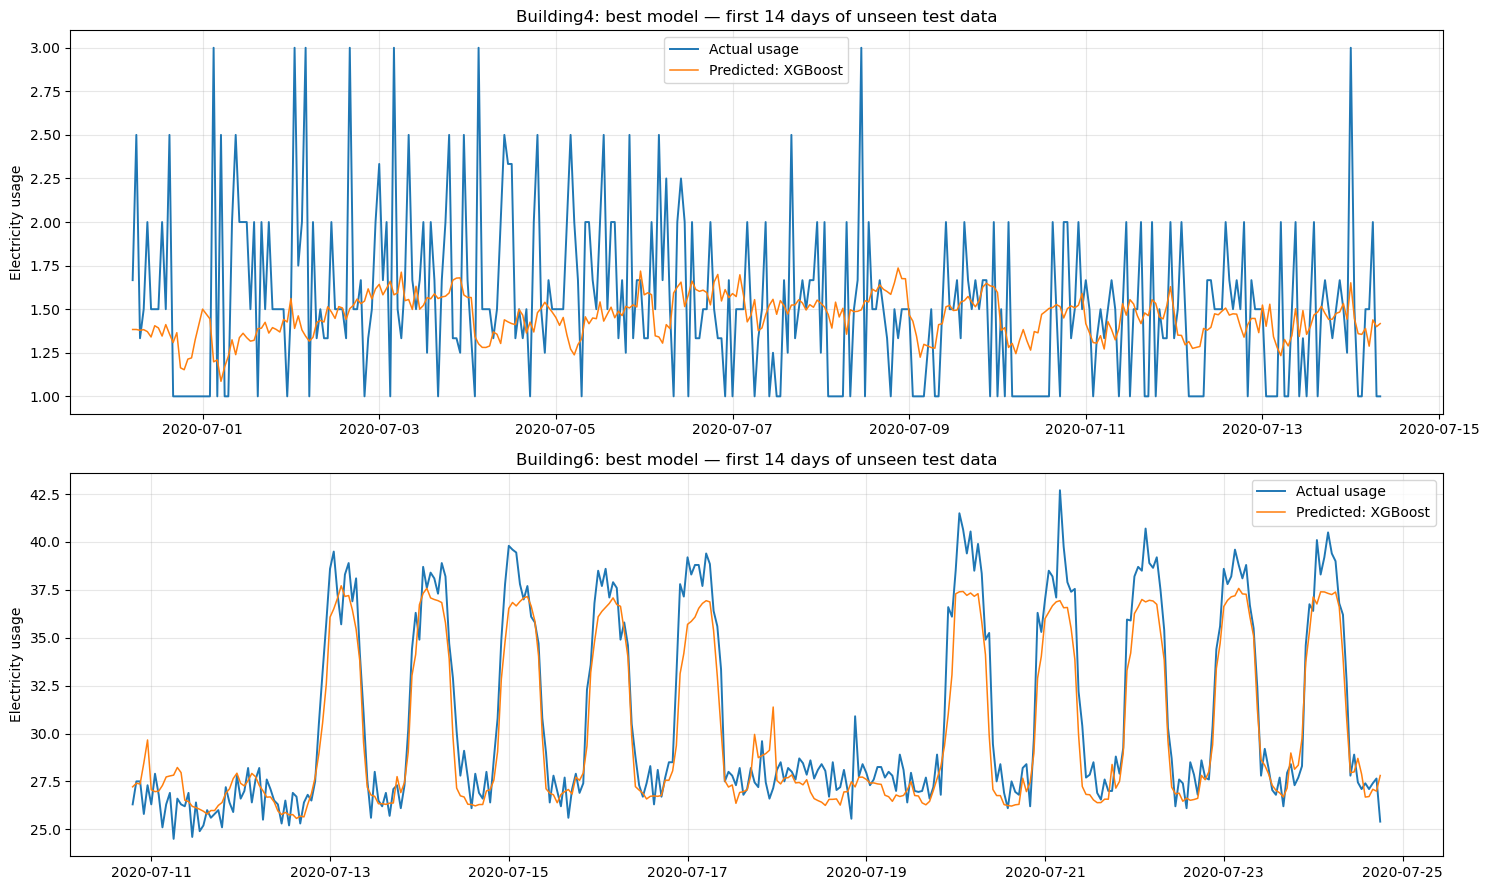

In [6]:
best_models = results.loc[results.groupby("Building")["RMSE"].idxmin()].copy()
best_models["Selection_rule"] = "Lowest RMSE on unseen final 20% of observations"
display(best_models.round(3))

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
for ax, building in zip(axes, ["Building4", "Building6"]):
    winner = best_models.loc[best_models["Building"] == building, "Model"].iloc[0]
    plot = predictions[(predictions["Building"] == building) & (predictions["Model"] == winner)].head(24 * 14)
    ax.plot(plot["datetime"], plot["Actual"], label="Actual usage", linewidth=1.4)
    ax.plot(plot["datetime"], plot["Predicted"], label=f"Predicted: {winner}", linewidth=1.1)
    ax.set_title(f"{building}: best model — first 14 days of unseen test data")
    ax.set_ylabel("Electricity usage")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Fine-tune the selected Gradient Boosting model

Parameter selection uses only the earlier part of the training period. The final 20% test period stays untouched until final evaluation.


In [ ]:
tuning_candidates = [
    {"n_estimators": 150, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 2},
    {"n_estimators": 250, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 3},
]

tuned_results, tuned_predictions = [], []
selected_tuning_parameters = {}
for building, data in model_datasets.items():
    feature_columns = [column for column in data.columns if column != "usage"]
    outer_split = int(len(data) * 0.80)
    outer_train, final_test = data.iloc[:outer_split], data.iloc[outer_split:]
    inner_split = int(len(outer_train) * 0.80)
    inner_train, validation = outer_train.iloc[:inner_split], outer_train.iloc[inner_split:]

    validation_scores = []
    for parameters in tuning_candidates:
        candidate = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **parameters)),
        ])
        # Evenly sample the earlier training history only for fast parameter selection.
        tuning_train = inner_train
        if len(tuning_train) > 2500:
            positions = np.linspace(0, len(tuning_train) - 1, 2500, dtype=int)
            tuning_train = tuning_train.iloc[positions]
        candidate.fit(tuning_train[feature_columns], tuning_train["usage"])
        validation_prediction = candidate.predict(validation[feature_columns])
        validation_scores.append({"parameters": parameters, "validation_RMSE": mean_squared_error(validation["usage"], validation_prediction) ** 0.5})

    best_validation = min(validation_scores, key=lambda item: item["validation_RMSE"])
    selected_tuning_parameters[building] = best_validation["parameters"]
    final_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **best_validation["parameters"])),
    ])
    final_model.fit(outer_train[feature_columns], outer_train["usage"])
    final_prediction = final_model.predict(final_test[feature_columns])
    final_score = score(final_test["usage"].to_numpy(), final_prediction)
    tuned_results.append({"Building": building, "Model": "Tuned Gradient Boosting", "validation_RMSE": best_validation["validation_RMSE"], "chosen_parameters": str(best_validation["parameters"]), **final_score})
    tuned_predictions.append(pd.DataFrame({"datetime": final_test.index, "Building": building, "Actual": final_test["usage"].to_numpy(), "Predicted": final_prediction}))

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.to_csv(OUTPUT_DIR / "tuned_gradient_boosting_results.csv", index=False)
pd.concat(tuned_predictions, ignore_index=True).to_csv(OUTPUT_DIR / "tuned_gradient_boosting_predictions.csv", index=False)
display(tuned_results_df.round(3))


## 8. Building 4: tune explicitly for ±10% match rate

This section selects parameters using only an earlier validation period, then evaluates the selected model once on the untouched final test period.


In [ ]:
building = "Building4"
data = model_datasets[building]
feature_columns = [column for column in data.columns if column != "usage"]
outer_split = int(len(data) * 0.80)
outer_train, final_test = data.iloc[:outer_split], data.iloc[outer_split:]
inner_split = int(len(outer_train) * 0.80)
inner_train, validation = outer_train.iloc[:inner_split], outer_train.iloc[inner_split:]

match_candidates = [
    ("Decision Tree", DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1)),
    ("Random Forest", RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1)),
    ("Random Forest", RandomForestRegressor(n_estimators=150, max_depth=None, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=1)),
]

match_validation = []
for name, estimator in match_candidates:
    candidate = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", estimator)])
    candidate.fit(inner_train[feature_columns], inner_train["usage"])
    prediction = candidate.predict(validation[feature_columns])
    validation_score = score(validation["usage"].to_numpy(), prediction)
    match_validation.append({"model": name, "estimator": estimator, "validation_match_rate": validation_score["Within_10pct_match_rate"], "validation_RMSE": validation_score["RMSE"]})

best_match = max(match_validation, key=lambda item: item["validation_match_rate"])
final_match_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", best_match["estimator"])])
final_match_model.fit(outer_train[feature_columns], outer_train["usage"])
final_prediction = final_match_model.predict(final_test[feature_columns])
final_match_score = score(final_test["usage"].to_numpy(), final_prediction)

building4_match_result = pd.DataFrame([{
    "Building": building,
    "selected_model": best_match["model"],
    "selected_parameters": str(best_match["estimator"].get_params()),
    "validation_match_rate": best_match["validation_match_rate"],
    **final_match_score,
}])
building4_match_result.to_csv(OUTPUT_DIR / "building4_match_rate_tuned_result.csv", index=False)
display(building4_match_result.round(3))


## 9. Train final production models on all complete available data

After the parameters were selected without using the final test period, the selected model is fitted on every available observed row for each building.


In [ ]:
from joblib import dump

final_model_summary = []
for building, data in model_datasets.items():
    feature_columns = [column for column in data.columns if column != "usage"]
    final_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **selected_tuning_parameters[building])),
    ])
    final_model.fit(data[feature_columns], data["usage"])
    model_path = OUTPUT_DIR / f"{building}_final_gradient_boosting.joblib"
    dump({"model": final_model, "feature_columns": feature_columns, "parameters": selected_tuning_parameters[building]}, model_path)
    final_model_summary.append({"Building": building, "training_rows": len(data), "training_start": data.index.min(), "training_end": data.index.max(), "model_file": str(model_path)})

final_model_summary = pd.DataFrame(final_model_summary)
final_model_summary.to_csv(OUTPUT_DIR / "final_full_data_model_summary.csv", index=False)
display(final_model_summary)


## 10. Visualise model performance and predictions

The bar charts compare every model on the same unseen test period. The line charts show whether the selected model follows the real hourly usage pattern.


In [ ]:
MODEL_COLORS = {"Building4": "#2E6FBB", "Building6": "#E6862C"}

# 1. Comparison charts: same test period, direct comparison across all models.
model_order = results.groupby("Model")["RMSE"].mean().sort_values().index.tolist()
plot_results = results.copy()
plot_results["Model"] = pd.Categorical(plot_results["Model"], categories=model_order, ordered=True)
plot_results = plot_results.sort_values("Model")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric, title, ylabel in [
    (axes[0], "Within_10pct_match_rate", "Model match rate on unseen test data", "Predictions within ±10% (%)"),
    (axes[1], "RMSE", "Model prediction error on unseen test data", "RMSE (lower is better)"),
]:
    pivot = plot_results.pivot(index="Model", columns="Building", values=metric)
    pivot.plot(kind="bar", ax=ax, color=[MODEL_COLORS["Building4"], MODEL_COLORS["Building6"]], width=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Building")
plt.tight_layout()
comparison_chart_path = OUTPUT_DIR / "all_models_comparison.png"
plt.savefig(comparison_chart_path, dpi=180, bbox_inches="tight")
plt.show()

# 2. Actual vs predicted: the model selected by lowest RMSE for each building.
best_for_visual = results.loc[results.groupby("Building")["RMSE"].idxmin()]
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
for ax, building in zip(axes, ["Building4", "Building6"]):
    selected_model = best_for_visual.loc[best_for_visual["Building"] == building, "Model"].iloc[0]
    line_data = predictions[(predictions["Building"] == building) & (predictions["Model"] == selected_model)].head(24 * 14)
    ax.plot(line_data["datetime"], line_data["Actual"], color="#1F2937", linewidth=1.5, label="Actual usage")
    ax.plot(line_data["datetime"], line_data["Predicted"], color=MODEL_COLORS[building], linewidth=1.2, label=f"Predicted — {selected_model}")
    ax.set_title(f"{building}: actual vs predicted usage (first 14 days of unseen test data)")
    ax.set_ylabel("Electricity usage")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
prediction_chart_path = OUTPUT_DIR / "best_model_actual_vs_predicted.png"
plt.savefig(prediction_chart_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved charts:", comparison_chart_path, "and", prediction_chart_path)


## Interpretation

Use the lowest RMSE as the main model-selection rule. `Within_10pct_match_rate` is a plain-language accuracy-like measure. The tuned Gradient Boosting result is evaluated only after parameter selection is finished.
